In [1]:
!pip install simpy
import simpy
import random
import pandas as pd
import numpy as np

def bank_simulation(env, num_tellers, arrival_interval, service_time_avg):
    bank_resource = simpy.Resource(env, capacity=num_tellers)
    wait_times = []

    def customer(env, name, bank_res, service_time):
        arrival_time = env.now
        with bank_res.request() as req:
            yield req
            wait_time = env.now - arrival_time
            wait_times.append(wait_time)
            yield env.timeout(random.expovariate(1.0 / service_time))

    def customer_generator(env, bank_res, interval, service_time):
        i = 0
        while True:
            yield env.timeout(random.expovariate(1.0 / interval))
            i += 1
            env.process(customer(env, f'Customer{i}', bank_res, service_time))

    env.process(customer_generator(env, bank_resource, arrival_interval, service_time_avg))
    env.run(until=480)

    if len(wait_times) > 0:
        return np.mean(wait_times)
    else:
        return 0

data = []

print("Starting 1000 simulations... this may take a moment.")

for i in range(1000):
    num_tellers = random.randint(1, 5)
    arrival_interval = random.uniform(2, 10)
    service_time_avg = random.uniform(5, 15)

    env = simpy.Environment()
    avg_wait = bank_simulation(env, num_tellers, arrival_interval, service_time_avg)

    data.append({
        "Number_of_Tellers": num_tellers,
        "Arrival_Interval": arrival_interval,
        "Service_Time_Avg": service_time_avg,
        "Average_Wait_Time": avg_wait
    })

df = pd.DataFrame(data)
print("Simulation Complete!")
print(df.head())

df.to_csv("bank_simulation_data.csv", index=False)


Starting 1000 simulations... this may take a moment.
Simulation Complete!
   Number_of_Tellers  Arrival_Interval  Service_Time_Avg  Average_Wait_Time
0                  3          7.533451          6.601456           0.226372
1                  3          7.052033         12.501500           0.877708
2                  3          7.192428          5.057895           0.005139
3                  2          5.814696          5.596231           1.425715
4                  1          4.419831         11.235891         158.693646


Training 8 models...
Running TOPSIS...
SUCCESS: File saved to result.csv
              Model          MSE       RMSE        MAE        R2  \
1      RandomForest   246.972828  15.715369   8.083614  0.898231   
7        ExtraTrees   251.705557  15.865231   8.408870  0.896281   
5               KNN   281.286258  16.771591   8.932412  0.884092   
2  GradientBoosting   324.894989  18.024844  10.501960  0.866122   
4      DecisionTree   389.762161  19.742395  10.310679  0.839392   
6          AdaBoost   590.636761  24.303020  20.084796  0.756619   
0  LinearRegression  1063.758908  32.615317  26.558294  0.561661   
3               SVR  1876.128805  43.314303  21.642060  0.226912   

   Topsis Score  Rank  
1      1.000000     1  
7      0.991725     2  
5      0.969573     3  
2      0.923924     4  
4      0.894179     5  
6      0.667979     6  
0      0.401065     7  
3      0.107837     8  


/tmp/ipython-input-1278286862.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Topsis Score", y="Model", data=final_df, palette="viridis")


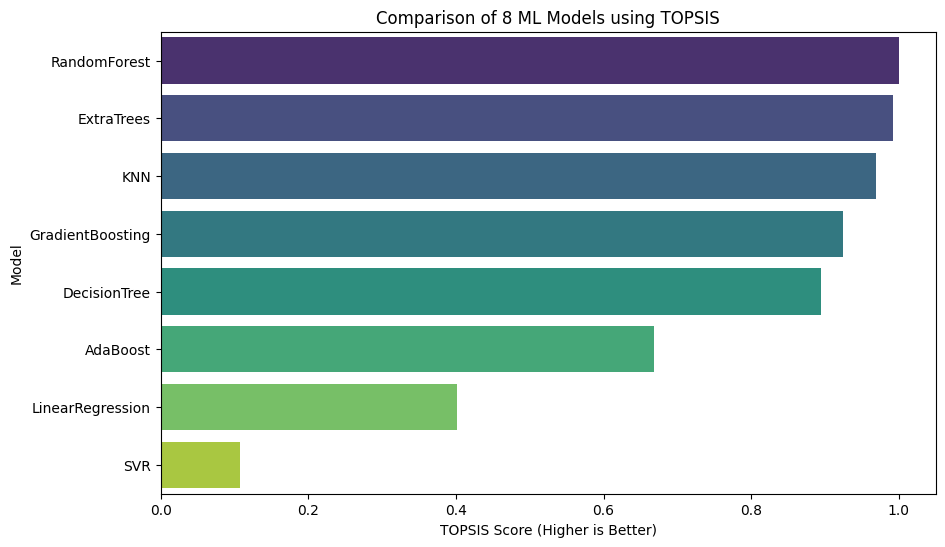

The Best Model is: RandomForest


In [2]:
!pip install Topsis-Gurdarshan-102303217

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, ExtraTreesRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

X = df[["Number_of_Tellers", "Arrival_Interval", "Service_Time_Avg"]]
y = df["Average_Wait_Time"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(),
    "GradientBoosting": GradientBoostingRegressor(),
    "SVR": SVR(),
    "DecisionTree": DecisionTreeRegressor(),
    "KNN": KNeighborsRegressor(),
    "AdaBoost": AdaBoostRegressor(),
    "ExtraTrees": ExtraTreesRegressor()
}

results = []

print(f"Training {len(models)} models...")

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

results_df = pd.DataFrame(results)
results_df.to_csv("model_performance.csv", index=False)

print("Running TOPSIS...")
!topsis model_performance.csv "1,1,1,1" "-,-,-,+" result.csv

final_df = pd.read_csv("result.csv").sort_values(by="Rank")
print(final_df)

plt.figure(figsize=(10, 6))
sns.barplot(x="Topsis Score", y="Model", data=final_df, palette="viridis")
plt.title("Comparison of 8 ML Models using TOPSIS")
plt.xlabel("TOPSIS Score (Higher is Better)")
plt.show()

winner = final_df.iloc[0]['Model']
print(f"The Best Model is: {winner}")
